# Data Information

Data source: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

# Problem Definition

bagaimana cara menentukan bonus karyawan yang optimal sesuai dengan kinerja dan posisi agar performa karyawan meningkat dan mengurangi kemungkinan karyawan untuk resign.

# Dataset

In [195]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

In [196]:
df = pd.read_csv('dataset/IBM-HR-Employee-Attrition.csv')

# Data Understanding

In [197]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [198]:
df.shape

(1470, 35)

In [199]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [200]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [201]:
df["JobRole"].value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

In [202]:
df["JobLevel"].value_counts()

JobLevel
1    543
2    534
3    218
4    106
5     69
Name: count, dtype: int64

In [203]:
df["JobInvolvement"].value_counts()

JobInvolvement
3    868
2    375
4    144
1     83
Name: count, dtype: int64

# Data Cleaning

- missing value
- remove duplicate
- handle inconsisten
- handle outlier

(karena kebetulan di kasus ini dataset very clean, maka saya skip step data cleaning ini, kecuali feature/variable yang tidak relevan)

### Check is null

In [204]:
countNull = df.isna().sum()
print(countNull)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Check is duplicate

In [205]:
df.duplicated().sum()

np.int64(0)

### Remove unnecessary column/feature/variable

In [206]:
df = df.drop(["Attrition", "BusinessTravel", "DistanceFromHome", "EmployeeCount", "EmployeeNumber", "EnvironmentSatisfaction", "Gender", "MaritalStatus", "Over18", "RelationshipSatisfaction", "StandardHours", "WorkLifeBalance", "MonthlyRate", "NumCompaniesWorked", "PercentSalaryHike", "StockOptionLevel"], axis=1)

In [207]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      1470 non-null   int64
 1   DailyRate                1470 non-null   int64
 2   Department               1470 non-null   str  
 3   Education                1470 non-null   int64
 4   EducationField           1470 non-null   str  
 5   HourlyRate               1470 non-null   int64
 6   JobInvolvement           1470 non-null   int64
 7   JobLevel                 1470 non-null   int64
 8   JobRole                  1470 non-null   str  
 9   JobSatisfaction          1470 non-null   int64
 10  MonthlyIncome            1470 non-null   int64
 11  OverTime                 1470 non-null   str  
 12  PerformanceRating        1470 non-null   int64
 13  TotalWorkingYears        1470 non-null   int64
 14  TrainingTimesLastYear    1470 non-null   int64
 15  YearsAtCompany 

### Ada data (Attrition, Overtime) yang kategorikal (Yes/No) maka perlu di ubah menjadi 1 dan 0 (Binary Encoding)

In [208]:
df["OverTime"] = df["OverTime"].map({"Yes": 1, "No": 0})

In [209]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      1470 non-null   int64
 1   DailyRate                1470 non-null   int64
 2   Department               1470 non-null   str  
 3   Education                1470 non-null   int64
 4   EducationField           1470 non-null   str  
 5   HourlyRate               1470 non-null   int64
 6   JobInvolvement           1470 non-null   int64
 7   JobLevel                 1470 non-null   int64
 8   JobRole                  1470 non-null   str  
 9   JobSatisfaction          1470 non-null   int64
 10  MonthlyIncome            1470 non-null   int64
 11  OverTime                 1470 non-null   int64
 12  PerformanceRating        1470 non-null   int64
 13  TotalWorkingYears        1470 non-null   int64
 14  TrainingTimesLastYear    1470 non-null   int64
 15  YearsAtCompany 

In [210]:
df.isna().sum()

Age                        0
DailyRate                  0
Department                 0
Education                  0
EducationField             0
HourlyRate                 0
JobInvolvement             0
JobLevel                   0
JobRole                    0
JobSatisfaction            0
MonthlyIncome              0
OverTime                   0
PerformanceRating          0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

### One hot encoding kategori (Department, EducationField, JobRole)

In [211]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      1470 non-null   int64
 1   DailyRate                1470 non-null   int64
 2   Department               1470 non-null   str  
 3   Education                1470 non-null   int64
 4   EducationField           1470 non-null   str  
 5   HourlyRate               1470 non-null   int64
 6   JobInvolvement           1470 non-null   int64
 7   JobLevel                 1470 non-null   int64
 8   JobRole                  1470 non-null   str  
 9   JobSatisfaction          1470 non-null   int64
 10  MonthlyIncome            1470 non-null   int64
 11  OverTime                 1470 non-null   int64
 12  PerformanceRating        1470 non-null   int64
 13  TotalWorkingYears        1470 non-null   int64
 14  TrainingTimesLastYear    1470 non-null   int64
 15  YearsAtCompany 

### one-hot encoding data kategorical non ordinal

In [212]:
df = pd.get_dummies(df, columns=["Department"], drop_first=False)

In [213]:
df = pd.get_dummies(df, columns=["EducationField"], drop_first=False)

In [214]:
df = pd.get_dummies(df, columns=["JobRole"], drop_first=False)

In [215]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   DailyRate                          1470 non-null   int64
 2   Education                          1470 non-null   int64
 3   HourlyRate                         1470 non-null   int64
 4   JobInvolvement                     1470 non-null   int64
 5   JobLevel                           1470 non-null   int64
 6   JobSatisfaction                    1470 non-null   int64
 7   MonthlyIncome                      1470 non-null   int64
 8   OverTime                           1470 non-null   int64
 9   PerformanceRating                  1470 non-null   int64
 10  TotalWorkingYears                  1470 non-null   int64
 11  TrainingTimesLastYear              1470 non-null   int64
 12  YearsAtCompany                 

### Ubah tipe data bool menjadi tipe data int

In [216]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [217]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   DailyRate                          1470 non-null   int64
 2   Education                          1470 non-null   int64
 3   HourlyRate                         1470 non-null   int64
 4   JobInvolvement                     1470 non-null   int64
 5   JobLevel                           1470 non-null   int64
 6   JobSatisfaction                    1470 non-null   int64
 7   MonthlyIncome                      1470 non-null   int64
 8   OverTime                           1470 non-null   int64
 9   PerformanceRating                  1470 non-null   int64
 10  TotalWorkingYears                  1470 non-null   int64
 11  TrainingTimesLastYear              1470 non-null   int64
 12  YearsAtCompany                 

### check isi column bool yang udah diubah menjadi int

# Untuk nyari korelasi semua column/feature/variable

In [218]:
df.corr(numeric_only="True")

,Age,DailyRate,Education,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,OverTime,PerformanceRating,...,EducationField_Technical Degree,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative
Age,1.000000,0.010661,0.208034,0.024287,0.029820,0.509604,-0.004892,0.497855,0.028062,0.001904,...,-0.027604,0.098825,-0.029856,-0.143176,0.294248,0.049726,0.185891,-0.146518,-0.002001,-0.175785
DailyRate,0.010661,1.000000,-0.016806,0.023381,0.046135,0.002966,0.030571,0.007707,0.009135,0.000473,...,0.030869,0.040141,-0.021156,-0.006728,-0.013224,-0.005302,-0.000021,-0.002624,-0.000513,0.005375
Education,0.208034,-0.016806,1.000000,0.016775,0.042438,0.101589,-0.011296,0.094961,-0.020322,-0.024539,...,-0.026742,0.024270,-0.005295,-0.063566,0.028453,-0.005290,0.049694,0.000709,0.053398,-0.091465
HourlyRate,0.024287,0.023381,0.016775,1.000000,0.042861,-0.027853,-0.071335,-0.015794,-0.007782,-0.002172,...,0.011283,0.014599,-0.016189,0.018028,0.012659,-0.014394,-0.025128,0.020034,-0.011886,-0.018703
JobInvolvement,0.029820,0.046135,0.042438,0.042861,1.000000,-0.012630,-0.021476,-0.015271,-0.003507,-0.029071,...,-0.004519,0.001272,-0.004952,-0.022724,0.017112,-0.021939,0.015200,0.047604,-0.011413,-0.027282
JobLevel,0.509604,0.002966,0.101589,-0.027853,-0.012630,1.000000,-0.001944,0.950300,0.000544,-0.021222,...,-0.054707,0.115704,-0.100922,-0.344608,0.552744,0.114896,0.414319,-0.387788,0.127490,-0.216559
JobSatisfaction,-0.004892,0.030571,-0.011296,-0.071335,-0.021476,-0.001944,1.000000,-0.007157,0.024539,0.002297,...,-0.019795,0.016367,-0.029681,-0.015710,-0.005620,-0.013747,-0.006217,0.020503,0.012604,0.001413
MonthlyIncome,0.497855,0.007707,0.094961,-0.015794,-0.015271,0.950300,-0.007157,1.000000,0.006089,-0.017120,...,-0.049695,0.068177,-0.092250,-0.320906,0.619573,0.055684,0.485818,-0.345180,0.047792,-0.201514
OverTime,0.028062,0.009135,-0.020322,-0.007782,-0.003507,0.000544,0.024539,0.006089,1.000000,0.004369,...,-0.017723,-0.000382,-0.014026,-0.044774,-0.011086,-0.010302,0.002400,0.054378,0.006341,0.003347
PerformanceRating,0.001904,0.000473,-0.024539,-0.002172,-0.029071,-0.021222,0.002297,-0.017120,0.004369,1.000000,...,-0.021729,-0.000928,-0.010154,0.010796,0.032050,0.029775,-0.035744,0.019416,-0.041401,-0.006214


### Pake seaborn correlation heatmap

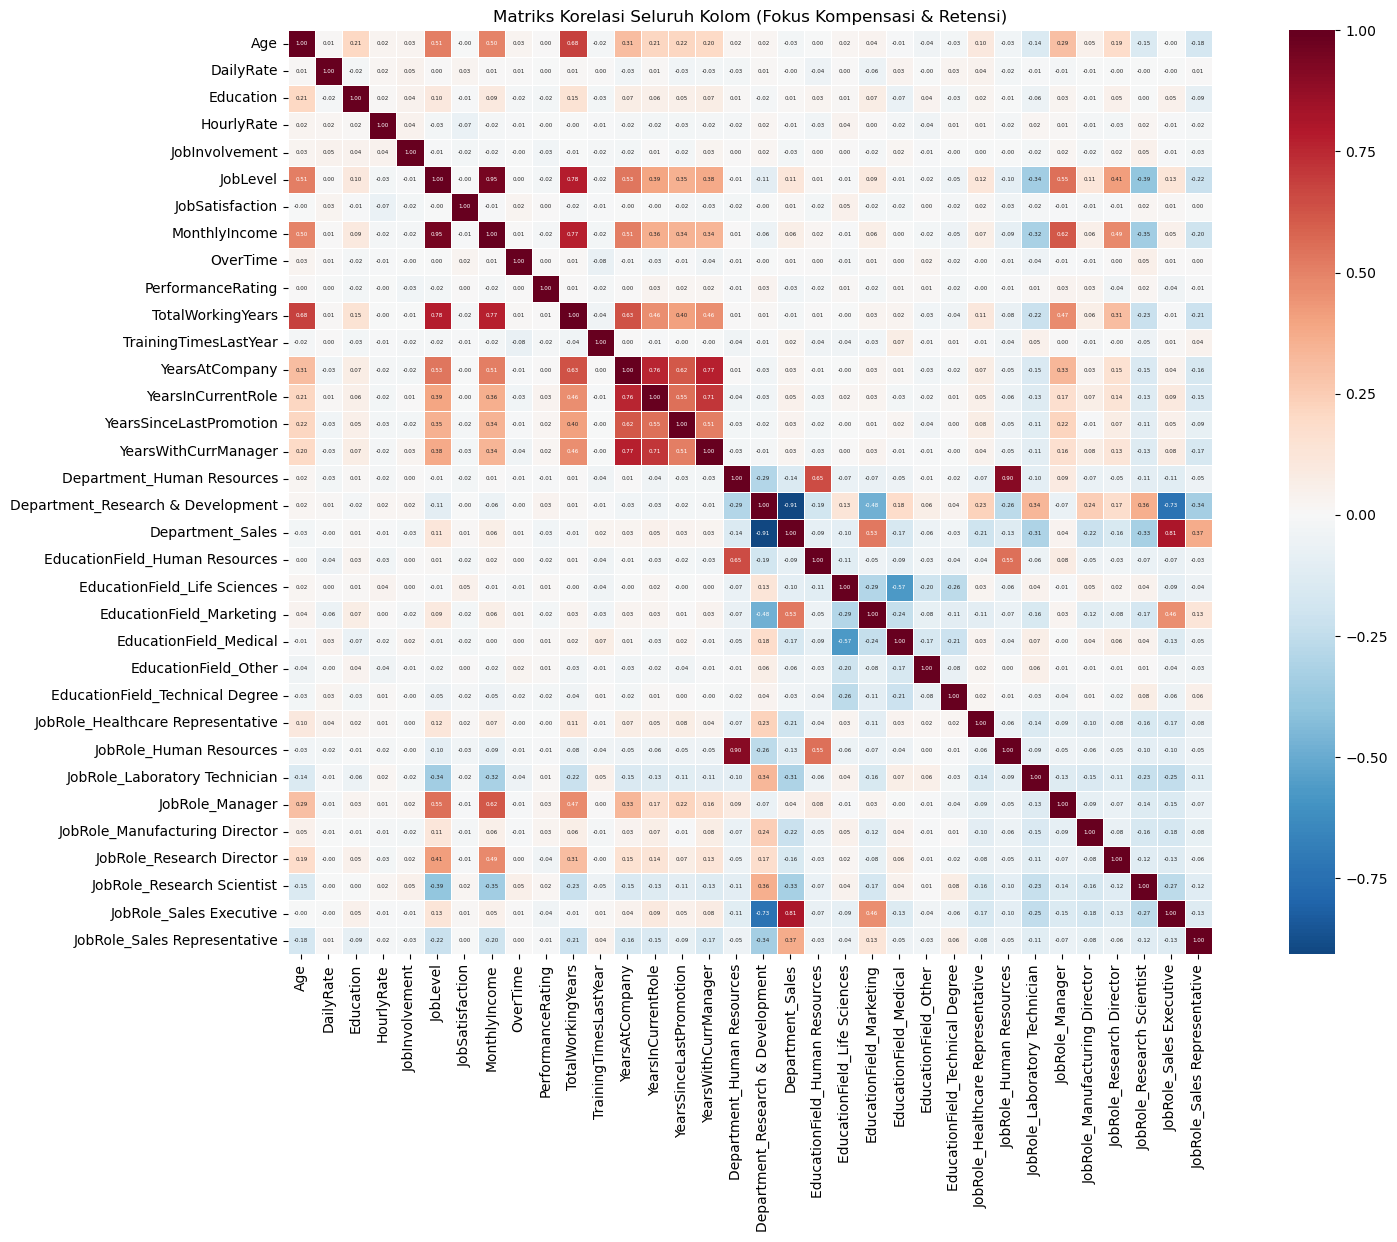

In [219]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(20, 12))

# Hitung matriks korelasi
corr_matrix = numeric_df.corr()

# Buat mask untuk menutupi bagian atas (agar tidak duplikat/simetris)
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Visualisasi
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r', 
            center=0,
            linewidths=0.5,
            square=True,
            annot_kws={"size": 4},)

plt.title("Matriks Korelasi Seluruh Kolom (Fokus Kompensasi & Retensi)")
plt.show()

### lihat penyebaran data dari mean (Standard Deviation)

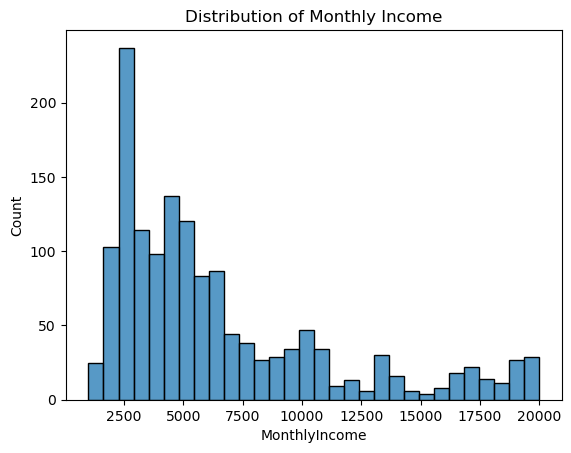

In [220]:
# Histogram
sns.histplot(df["MonthlyIncome"], bins=30)
plt.title("Distribution of Monthly Income")
plt.show()

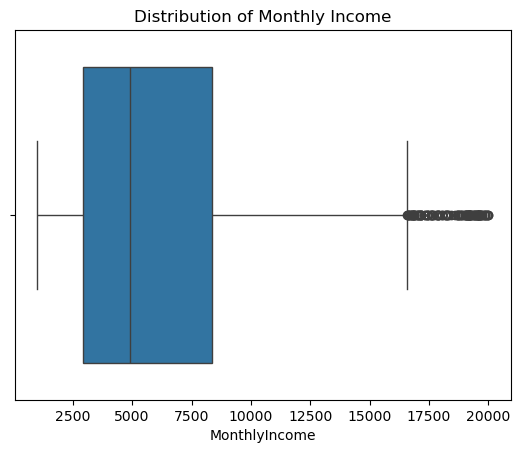

In [221]:
# Box Plot
sns.boxplot(x=df["MonthlyIncome"])
plt.title("Distribution of Monthly Income")
plt.show()

### Create linear scaling berbasis baseline (min $1000, max $20000) menjadi (min Rp.1.250.000, max Rp.25.000.000)
### agar data dari gaji luar negeri sesuai dengan kondisi gaji di indonesia

In [222]:
scale = 1_250_000 / df["MonthlyIncome"].min()

df["MonthlyRupiah"] = df["MonthlyIncome"] * scale
df["MonthlyRupiah"]= df["MonthlyRupiah"].round(0).astype(int)

In [223]:
df[["MonthlyIncome", "MonthlyRupiah"]]

,MonthlyIncome,MonthlyRupiah
0,5993,7424430
1,5130,6355302
2,2090,2589197
3,2909,3603816
4,3468,4296333
...,...,...
1465,2571,3185084
1466,9991,12377354
1467,6142,7609019
1468,5390,6677403


### Visualisasi Density Plot untuk melihat konsentrasi gaji karyawan

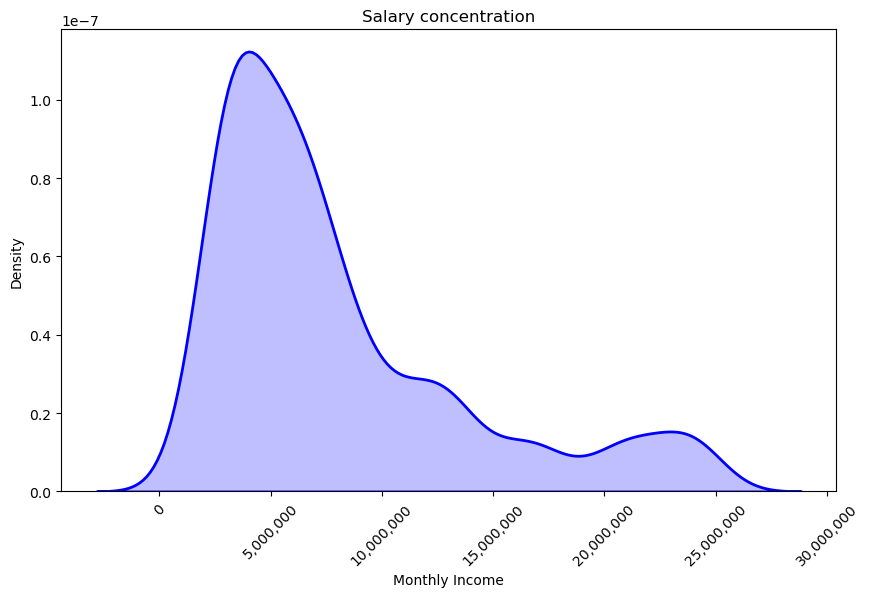

In [224]:
plt.figure(figsize=(10, 6))
plot = sns.kdeplot(df["MonthlyRupiah"], fill="True", color="blue", linewidth=2) #KDE = Kernel Density Estimate

# Mengubah format angka di sumbu X menjadi desimal biasa (bukan scientific)
# 'f' artinya float, ',.0f' artinya menggunakan pemisah ribuan dan 0 angka di belakang koma
plot.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # set_major_formatter = mengatur format tampilan teks

plt.title("Salary concentration")
plt.xlabel("Monthly Income")
plt.ylabel("Density")
plt.xticks(rotation=45) # Memutar angka agar tidak bertumpuk jika terlalu panjang
plt.show()

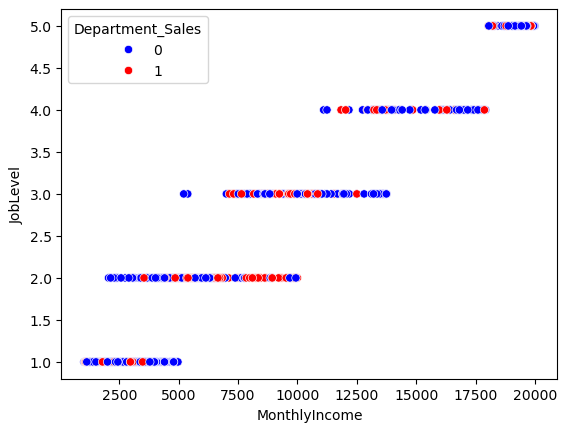

In [225]:
sns.scatterplot(data=df, x="MonthlyIncome", y="JobLevel", hue="Department_Sales",
    palette=["blue", "red"])
plt.show()

# Metode untuk menemukan korelasi
### - Pairplot
### - PCA
### - model-based exploration

### Model Based Exploration (menggunakan model simple untuk menemukan korelasi)

## Notes
## rule-based menentukan range
## ML menentukan angka di dalam range scaling (0 - 1)

## 1. Define all range

In [226]:
# YearsAtCompany
def enforce_min_bonus_multiplier(years):
    if years >= 1:
        return 1.01   # kalo udah kerja >= 1 tahun, pasti minimal dapat 1x gaji
    else:
        return 0.5

In [227]:
# Python dictionary
joblevel_bonus_range = {
    1: (0.5, 1.5),
    2: (0.5, 1.5),
    3: (1.0, 2.0),
    4: (1.5, 3.0),
    5: (2.0, 4.0)
}

In [228]:
def generate_target_bonus(row):
    # ubah jadi skala rating 1 - 4 (rating 1 = 0, rating 4 = 1.0)
    perf = (row["PerformanceRating"] - 1) / 3 # min-max scaling(-1 karnena nilai terendah adalah 1, "1 - 1 = 0", "4 - 1 = 3")
    jobinv = (row["JobInvolvement"] - 1) / 3
    tenure = min(row["YearsAtCompany"] / 20, 1.0) # min() memastikan orang yang kerja diatas 10 tahun tetap maksimal 1.0
    overtime = 1 if row["OverTime"] == 1 else 0 # jika lembur dapat 1, jika tidak dapat 0
    joblevel = np.log1p(row["JobLevel"]) / np.log1p(5) # skala logaritmik = level 1 ke 2 beda dampak skor nya besar
    # log1p = logaritma + 1, log1p(5) karena angka maks adalah 5

    base_score = (
        perf * 0.30 +
        jobinv * 0.25 +
        tenure * 0.15 +
        overtime * 0.07 +
        joblevel * 0.23
    )

    noise = np.random.normal(0, 0.03) # normal(loc, scale), 
    # noise = variasi acak yang tidak dapat di jelaskan oleh variable utama
    # loc(Mean) = titik tengah distribusi, 
    # scale(Standard Deviation) = tingkat penyebaran / "kekuatan" gangguan, 0.03 = gangguan 3%

    score = base_score + noise

    # HARD RULE: tenure >= 1 year guarantee minimum bonus
    if row["YearsAtCompany"] >= 1:
        score = max(score, 0.5)   # minimum floor (relative scale)
        # max() = jika score dibawa 0.5 maka akan di paksa minimal 0.5

    return score

In [229]:
df["BonusScore"] = df.apply(generate_target_bonus, axis=1)
# axis=1 artiya horizontal, karena kolom ["BonusScore"] membutuhkan data dari kolom horizontal lain

# global min-max → y in [0,1]
y_scaler = MinMaxScaler(feature_range=(0, 1)) # membuat rentang data antara 0 - 1, berasal dari sklearn.preprocessing
df["BonusScore"] = y_scaler.fit_transform(df[["BonusScore"]]) # DATA LEAKAGE RINGAN karena cuma di target y

In [230]:
X = df[[
    "PerformanceRating",
    "JobInvolvement",
    "JobLevel",
    "YearsAtCompany", 
    "OverTime"
]]

y = df["BonusScore"]

In [231]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    max_depth=3,
    n_estimators=200,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [232]:
def predict_relative(model, X):
    pred = model.predict(X)
    return np.clip(pred, 0, 1) # clip = membatasi range, "jika -0.5 makan akan 0", "jika 1.3 maka jadi 1.0"

y_pred = predict_relative(model, X_test)

In [233]:
def final_predict(X, y_pred):
    results = []

    for years, job_level, p in zip(X["YearsAtCompany"], X["JobLevel"], y_pred):

        low, high = joblevel_bonus_range[job_level]
        value = low + (high - low) * p # p adalah hasil prediksi ML

        # HARD RULE FINAL LAYER
        if years >= 1:
            value = max(value, 1.0)   # minimal 1x salary untuk karyawan yang sudah 1 tahun bekerja

        results.append(value)

    return np.array(results)    

In [234]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_test_pred = np.clip(y_test_pred, 0, 1)

final_output = final_predict(X_test, y_test_pred)

In [235]:
print("MAE Train:", mean_absolute_error(y_train, y_train_pred))
print("MAE Test :", mean_absolute_error(y_test, y_test_pred))

print("R2 Train:", r2_score(y_train, y_train_pred))
print("R2 Test :", r2_score(y_test, y_test_pred))

print("RMSE :")
print("RMSE: ")

print("MAPE: ")

MAE Train: 0.03401755263754402
MAE Test : 0.03710506892373949
R2 Train: 0.8948055356539071
R2 Test : 0.8790311650162139
RMSE :
RMSE: 
MAPE: 


In [236]:
for jl in sorted(X_test["JobLevel"].unique()):
    vals = final_output[X_test["JobLevel"] == jl]
    low, high = joblevel_bonus_range[jl]

    print(
        f"JobLevel {jl} → "
        f"min={vals.min():.2f} (≥{low}), "
        f"max={vals.max():.2f} (≤{high})"
    )

JobLevel 1 → min=0.74 (≥0.5), max=1.12 (≤1.5)
JobLevel 2 → min=0.84 (≥0.5), max=1.28 (≤1.5)
JobLevel 3 → min=1.37 (≥1.0), max=1.76 (≤2.0)
JobLevel 4 → min=2.21 (≥1.5), max=2.80 (≤3.0)
JobLevel 5 → min=3.00 (≥2.0), max=3.57 (≤4.0)


# Evaluation Metrics

### Visual Check

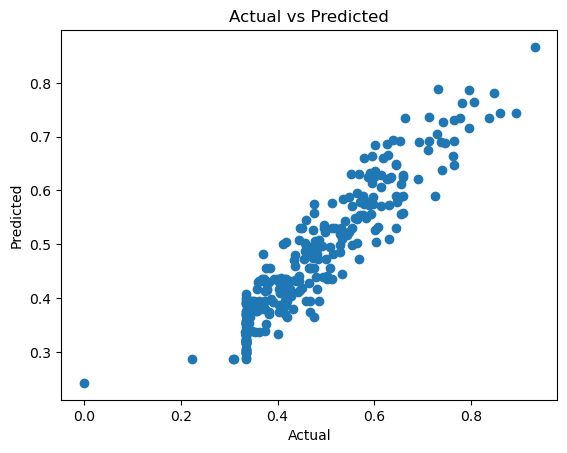

In [237]:
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# Feature Importance

In [238]:
importance = model.feature_importances_

pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

,Feature,Importance
2,JobLevel,0.299022
0,PerformanceRating,0.181346
3,YearsAtCompany,0.177853
1,JobInvolvement,0.175199
4,OverTime,0.166580


# Check plot manual

In [247]:
df[df["JobLevel"] == 4 ][["JobLevel", "BonusScore"]].min()

JobLevel      4.000000
BonusScore    0.334856
dtype: float64

In [240]:
df[["MonthlyIncome","BonusScore"]].head(10)

,MonthlyIncome,BonusScore
0,5993,0.536583
1,5130,0.527607
2,2090,0.253857
3,2909,0.436321
4,3468,0.334856
5,3068,0.334856
6,2670,0.628563
7,2693,0.506825
8,9526,0.485786
9,5237,0.452443


In [241]:
df[df["JobLevel"] == 3][["JobLevel", "BonusScore"]].min()

JobLevel      3.000000
BonusScore    0.334856
dtype: float64

In [242]:
def calculate_annual_bonus(row):
    low, high = joblevel_bonus_range[row["JobLevel"]]

    multiplier = low + (high - low) * row["BonusScore"]

    annual = row["MonthlyIncome"] * multiplier

    # HARD RULE FINAL LAYER
    if row["YearsAtCompany"] >= 1:
        annual = max(annual, row["MonthlyIncome"])

    return annual

In [243]:
df["AnnualBonus"] = df.apply(calculate_annual_bonus, axis=1)

In [244]:
df[df["AnnualBonus"] < df["MonthlyIncome"]][["MonthlyIncome", "AnnualBonus", "YearsAtCompany"]]

,MonthlyIncome,AnnualBonus,YearsAtCompany
2,2090,1575.562116,0
23,1232,891.543092,0
86,2322,1801.665173,0
109,2871,2034.081331,0
127,1675,1322.016920,0
171,2325,1496.436294,0
264,3485,2906.417575,0
265,6644,5210.732734,0
296,1420,1077.894058,0
301,1200,722.719660,0


In [245]:
new_dataset = df.copy()
new_dataset.to_csv("new_dataset_new.csv", index=False)

# Setelah model stabil -> masuk ke hyperparameter tuning

## GridSearch

In [246]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [2, 3, 4],
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 1, 5],
    "reg_lambda": [1, 5, 10]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score :", -grid.best_score_)


Fitting 3 folds for each of 2187 candidates, totalling 6561 fits
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.7}
Best Score : 0.03206342832623803


## Optuna (Advance)

In [58]:
X_model = df.drop(["BonusScore"], axis=1)
y_model = df["BonusScore"]

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42
)

# simpan versi CLEAN
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

In [63]:
import optuna
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10)
    }

    model = XGBRegressor(**params)
    model.fit(X_train_clean, y_train)

    preds = model.predict(X_test_clean)
    mae = mean_absolute_error(y_test, preds)

    return mae

In [64]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best Params:", study.best_params)
print("Best MAE   :", study.best_value)

[I 2026-04-21 07:55:14,606] A new study created in memory with name: no-name-b2357b17-c2b9-4d7b-912a-3bc718d71d59
[I 2026-04-21 07:55:14,757] Trial 0 finished with value: 0.04826569603533102 and parameters: {'max_depth': 4, 'n_estimators': 289, 'learning_rate': 0.19864253933256007, 'subsample': 0.6070678449439216, 'colsample_bytree': 0.9889863035440375, 'reg_alpha': 3.9910176288781605, 'reg_lambda': 1.747444277215707}. Best is trial 0 with value: 0.04826569603533102.
[I 2026-04-21 07:55:14,949] Trial 1 finished with value: 0.04946226621671824 and parameters: {'max_depth': 4, 'n_estimators': 299, 'learning_rate': 0.0511041845070901, 'subsample': 0.9964656624388477, 'colsample_bytree': 0.8175621985705808, 'reg_alpha': 5.122209877586515, 'reg_lambda': 8.388242719634913}. Best is trial 0 with value: 0.04826569603533102.
[I 2026-04-21 07:55:15,037] Trial 2 finished with value: 0.059659896858458586 and parameters: {'max_depth': 2, 'n_estimators': 215, 'learning_rate': 0.10011688210044521, 's

Best Params: {'max_depth': 3, 'n_estimators': 212, 'learning_rate': 0.1554823002492932, 'subsample': 0.8647402682291369, 'colsample_bytree': 0.6127856868201608, 'reg_alpha': 0.07013950674393055, 'reg_lambda': 7.836368767592615}
Best MAE   : 0.03697804956742365


## 1. Retrain Final Model

In [65]:
best_model = XGBRegressor(**study.best_params)
best_model.fit(X_train_clean, y_train)

y_pred = best_model.predict(X_test_clean)

print("MAE: ", mean_absolute_error(y_test, y_pred))

MAE:  0.03697804956742365


In [62]:
# target harus < 1, ini 2 berarti besar

## 2. Check Overfitting lagi

In [2247]:
# y_train_pred = best_model.predict(X_train_clean)

print("Train MAE: ", mean_absolute_error(y_train, y_train_pred))
print("Predict MAE: ", mean_absolute_error(y_test, y_pred))

Train MAE:  0.02865466463597512
Predict MAE:  0.03622079421654653


## 3. Feature Importance

In [66]:
importance = best_model.feature_importances_

pd.DataFrame({
    "Feature": X_train_clean.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False).head(20)

,Feature,Importance
9,PerformanceRating,0.182196
4,JobInvolvement,0.161059
35,AnnualBonus,0.143923
12,YearsAtCompany,0.130529
8,OverTime,0.126396
5,JobLevel,0.073921
15,YearsWithCurrManager,0.027789
13,YearsInCurrentRole,0.021786
30,JobRole_Research Director,0.012865
17,Department_Research & Development,0.009807


# Warning

In [67]:
# generate_target_bonus() -> Model belajar dari rumus buatan sendiri

# Next Level

In [68]:
### Optimasi Bonus Performa
# - performance
# - joblevel
# - tenure
# - dll

# -> bukan cuma model, tapi business logic

In [69]:
### Budget Constrains
# Total bonus <= 20% total salary company

In [70]:
### Fairness System
# JobLevel 5 > JobLevel 1 (secara konsisten) -> untuk menghindari bias model

In [71]:
df["BonusScore"].head(10)

0    0.559916
1    0.422762
2    0.173885
3    0.322252
4    0.311408
5    0.311408
6    0.643157
7    0.365162
8    0.553862
9    0.417978
Name: BonusScore, dtype: float64

In [72]:
df.corr()["BonusScore"].sort_values()

JobRole_Laboratory Technician       -0.198643
JobRole_Research Scientist          -0.195077
JobRole_Sales Representative        -0.161954
JobRole_Human Resources             -0.060979
TrainingTimesLastYear               -0.060897
EducationField_Technical Degree     -0.053246
Department_Research & Development   -0.036038
EducationField_Other                -0.015257
JobSatisfaction                     -0.005281
Department_Human Resources           0.002017
EducationField_Marketing             0.002958
HourlyRate                           0.004195
EducationField_Human Resources       0.006647
DailyRate                            0.006875
EducationField_Life Sciences         0.014810
EducationField_Medical               0.020704
Department_Sales                     0.036408
JobRole_Sales Executive              0.056665
JobRole_Manufacturing Director       0.068553
JobRole_Healthcare Representative    0.085601
Education                            0.085783
JobRole_Research Director         

In [73]:
df["FinalBonus"] = ((df["MonthlyIncome"] * df["BonusScore"]) / 100).astype(int)

In [74]:
df[["MonthlyIncome", "BonusScore", "FinalBonus"]].head(10)

,MonthlyIncome,BonusScore,FinalBonus
0,5993,0.559916,33
1,5130,0.422762,21
2,2090,0.173885,3
3,2909,0.322252,9
4,3468,0.311408,10
5,3068,0.311408,9
6,2670,0.643157,17
7,2693,0.365162,9
8,9526,0.553862,52
9,5237,0.417978,21


## Analysis Mode

## Production Mode